## FINE-TUNING VGG16 for image classification

Loading the dataset **"full_df.csv"** and storing the dataframe inside the vairable called **df**

# Multi-class classification for coloured images

In [2]:
import pandas as pd
df = pd.read_csv('full_df.csv')

Printing the dataframe

In [3]:
df

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6387,4686,63,Male,4686_left.jpg,4686_right.jpg,severe nonproliferative retinopathy,proliferative diabetic retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4686_left.jpg
6388,4688,42,Male,4688_left.jpg,4688_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4688_left.jpg
6389,4689,54,Male,4689_left.jpg,4689_right.jpg,mild nonproliferative retinopathy,normal fundus,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4689_left.jpg
6390,4690,57,Male,4690_left.jpg,4690_right.jpg,mild nonproliferative retinopathy,mild nonproliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4690_left.jpg


In [4]:
df['target'] = df['target'].astype(str)


Selecting 1000 samples for each class. For the classes where number of samples are less than that of 1000 the data is upsampled and for classes where data has samples more than 1000 are downsampled.
\
The total number of samples selected are 8000 (1000 samples per class, total 8 classes) 

In [5]:
import pandas as pd

TARGET_SAMPLES = 1000
RANDOM_STATE = 42

balanced_dfs = []

for cls in df['target'].unique():
    class_df = df[df['target'] == cls]

    if len(class_df) > TARGET_SAMPLES:
        class_df = class_df.sample(
            n=TARGET_SAMPLES,
            random_state=RANDOM_STATE
        )
    else:
        class_df = class_df.sample(
            n=TARGET_SAMPLES,
            replace=True,
            random_state=RANDOM_STATE
        )

    balanced_dfs.append(class_df)
df_balanced = pd.concat(balanced_dfs).reset_index(drop=True)


In [6]:
print(df_balanced['target'].value_counts())


target
[1, 0, 0, 0, 0, 0, 0, 0]    1000
[0, 1, 0, 0, 0, 0, 0, 0]    1000
[0, 0, 0, 0, 0, 0, 0, 1]    1000
[0, 0, 0, 0, 0, 0, 1, 0]    1000
[0, 0, 0, 0, 0, 1, 0, 0]    1000
[0, 0, 0, 1, 0, 0, 0, 0]    1000
[0, 0, 0, 0, 1, 0, 0, 0]    1000
[0, 0, 1, 0, 0, 0, 0, 0]    1000
Name: count, dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temp
df_train, df_temp = train_test_split(
    df_balanced,
    test_size=0.20,
    random_state=42,
    stratify=df_balanced['target']
)
# Split 30% → 15% val + 15% test
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=42,
    stratify=df_temp['target']
)



**The dataset is split to train, test and validation dataset with the following distribution:**
1. Train dataset size : 6400
2. Test Dataset size  : 800
3. Validation Dataset Size : 800


In [8]:
print("Train size:", len(df_train))
print("Validation size:", len(df_val))
print("Test size:", len(df_test))

print("\nClass distribution (Train):")
print(df_train['target'].value_counts())

print("\nClass distribution (Validation):")
print(df_val['target'].value_counts())

print("\nClass distribution (Test):")
print(df_test['target'].value_counts())


Train size: 6400
Validation size: 800
Test size: 800

Class distribution (Train):
target
[0, 0, 1, 0, 0, 0, 0, 0]    800
[0, 0, 0, 0, 0, 0, 1, 0]    800
[0, 0, 0, 0, 0, 0, 0, 1]    800
[1, 0, 0, 0, 0, 0, 0, 0]    800
[0, 1, 0, 0, 0, 0, 0, 0]    800
[0, 0, 0, 0, 1, 0, 0, 0]    800
[0, 0, 0, 0, 0, 1, 0, 0]    800
[0, 0, 0, 1, 0, 0, 0, 0]    800
Name: count, dtype: int64

Class distribution (Validation):
target
[0, 0, 0, 0, 0, 0, 1, 0]    100
[0, 0, 0, 1, 0, 0, 0, 0]    100
[0, 0, 1, 0, 0, 0, 0, 0]    100
[0, 0, 0, 0, 0, 1, 0, 0]    100
[0, 0, 0, 0, 0, 0, 0, 1]    100
[0, 1, 0, 0, 0, 0, 0, 0]    100
[1, 0, 0, 0, 0, 0, 0, 0]    100
[0, 0, 0, 0, 1, 0, 0, 0]    100
Name: count, dtype: int64

Class distribution (Test):
target
[1, 0, 0, 0, 0, 0, 0, 0]    100
[0, 0, 0, 0, 0, 0, 0, 1]    100
[0, 0, 0, 0, 0, 1, 0, 0]    100
[0, 1, 0, 0, 0, 0, 0, 0]    100
[0, 0, 0, 0, 1, 0, 0, 0]    100
[0, 0, 0, 0, 0, 0, 1, 0]    100
[0, 0, 0, 1, 0, 0, 0, 0]    100
[0, 0, 1, 0, 0, 0, 0, 0]    100
Name: count, dt

In [9]:
df_train['target'] = df_train['target'].astype(str)
df_val['target']   = df_val['target'].astype(str)
df_test['target']  = df_test['target'].astype(str)


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (100, 100)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
image_folder = 'resized_images'
IMG_SIZE = (100, 100)
BATCH_SIZE = 16


In [12]:
train_generator = train_datagen.flow_from_dataframe(
    df_train,
    directory=image_folder,
    x_col='filename',
    y_col='target',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    df_val,
    directory=image_folder,
    x_col='filename',
    y_col='target',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    df_test,
    directory=image_folder,
    x_col='filename',
    y_col='target',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 6400 validated image filenames belonging to 8 classes.
Found 800 validated image filenames belonging to 8 classes.
Found 800 validated image filenames belonging to 8 classes.


In [13]:
print("Classes:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Val samples:", val_generator.samples)
print("Test samples:", test_generator.samples)


Classes: {'[0, 0, 0, 0, 0, 0, 0, 1]': 0, '[0, 0, 0, 0, 0, 0, 1, 0]': 1, '[0, 0, 0, 0, 0, 1, 0, 0]': 2, '[0, 0, 0, 0, 1, 0, 0, 0]': 3, '[0, 0, 0, 1, 0, 0, 0, 0]': 4, '[0, 0, 1, 0, 0, 0, 0, 0]': 5, '[0, 1, 0, 0, 0, 0, 0, 0]': 6, '[1, 0, 0, 0, 0, 0, 0, 0]': 7}
Train samples: 6400
Val samples: 800
Test samples: 800


**Fine-tuning VGG-16 for coloured images for multi classification task with 4 different combinations of hyperparameters**
\
Experiments with 22 Epochs for each experiment
1.    (4, "adam", 1e-4),
2.    (6, "adam", 5e-4),
3.    (4, "rmsprop", 1e-4),
4.    (6, "rmsprop",  5e-4)

**Training the model for coloured images for multiclassification task with best parameters for coloured images which are as follows**:

1. unfrozen layers : last 4
2. Optmizer: Adam Optmizer
3. Learnign rate : 0.0001
4. Epochs : 40

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,384 (56.39 MB)

 Trainable params: 7,146,120 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 177s 439ms/step - accuracy: 0.3713 - loss: 1.6418 - val_accuracy: 0.3887 - val_loss: 1.5455
Epoch 2/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 103s 256ms/step - accuracy: 0.4453 - loss: 1.4359 - val_accuracy: 0.4988 - val_loss: 1.2944
Epoch 3/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 103s 256ms/step - accuracy: 0.4722 - loss: 1.3634 - val_accuracy: 0.5312 - val_loss: 1.2249
Epoch 4/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 103s 256ms/step - accuracy: 0.5011 - loss: 1.2971 - val_accuracy: 0.5462 - val_loss: 1.1737
Epoch 5/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 103s 257ms/step - accuracy: 0.5248 - loss: 1.2347 - val_accuracy: 0.5300 - val_loss: 1.2033
Epoch 6/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 104s 259ms/step - accuracy: 0.5489 - loss: 1.1780 - val_accuracy: 0.5788 - val_loss: 1.0828
Epoch 7/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 103s 257ms/step - accuracy: 0.5686 - loss: 1.1260 - val_accuracy: 0.5825 - val_loss: 1.0781
Epoch 8/40
400/400 ━━━━━━━━━━━━━━━━━━━━ 103s 258ms/step - accuracy: 0.5831 -

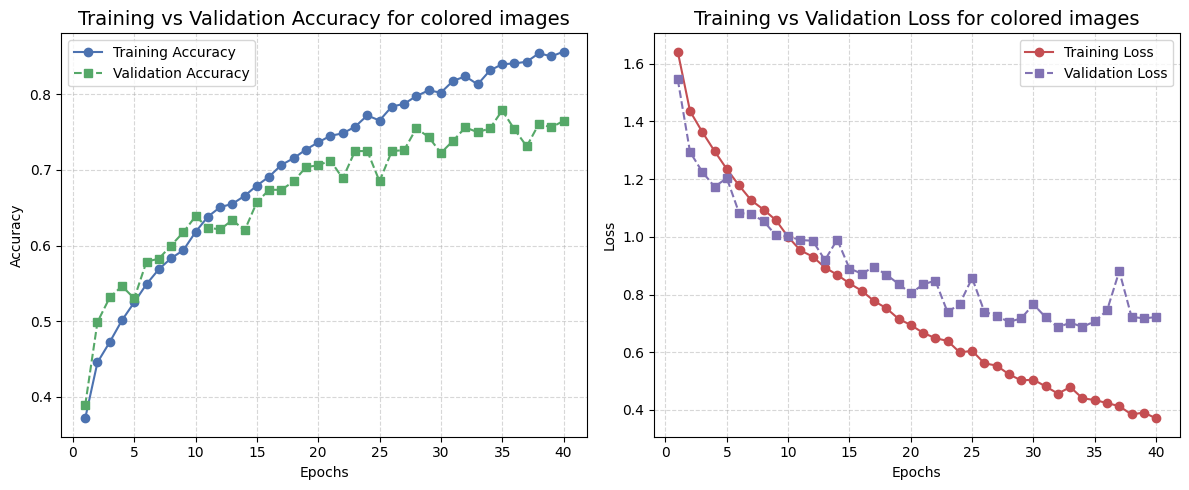

In [15]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.layers import GlobalAveragePooling2D
NUM_CLASSES = 8

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(100, 100, 3)
)

for layer in base_model.layers[:-4]:  
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),   
    Dropout(0.4),   
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),   
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
from tensorflow.keras.callbacks import EarlyStopping


steps_per_epoch = train_generator.samples // train_generator.batch_size
val_steps = val_generator.samples // val_generator.batch_size

history_best_colored = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    epochs=40,
    verbose=1
)
# plotting the results to showcase training accuracy and validation accuracy over epochs , training loss and validation loss over epochs
import matplotlib.pyplot as plt
acc = history_best_colored.history['accuracy']
val_acc = history_best_colored.history['val_accuracy']
loss = history_best_colored.history['loss']
val_loss = history_best_colored.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'o-', label='Training Accuracy', color='#4C72B0')
plt.plot(epochs, val_acc, 's--', label='Validation Accuracy', color='#55A868')
plt.title('Training vs Validation Accuracy for colored images', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'o-', label='Training Loss', color='#C44E52')
plt.plot(epochs, val_loss, 's--', label='Validation Loss', color='#8172B3')
plt.title('Training vs Validation Loss for colored images', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()
model.save('vgg16_odir.h5')